<a href="https://colab.research.google.com/github/Nihat0311/Machine-Learning/blob/main/Diamondsipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!curl -L -o diamonds.zip\
  https://www.kaggle.com/api/v1/datasets/download/shivam2503/diamonds

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  733k  100  733k    0     0  2135k      0 --:--:-- --:--:-- --:--:-- 2135k


In [2]:
!unzip /content/diamonds.zip

Archive:  /content/diamonds.zip
  inflating: diamonds.csv            


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet ,SGDRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor, AdaBoostClassifier, AdaBoostRegressor, BaggingClassifier, BaggingRegressor, VotingClassifier, StackingClassifier, StackingRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor

from sklearn.datasets import make_classification, make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [4]:
import pandas as pd
df = pd.read_csv('/content/diamonds.csv')
df

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [5]:
df.drop('Unnamed: 0',axis=1,inplace=True)
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [6]:
df.isna().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [7]:
clarity_map = {
    "IF": 8,
    "VVS1": 7,
    "VVS2": 6,
    "VS1": 5,
    "VS2": 4,
    "SI1": 3,
    "SI2": 2,
    "I1": 1
}

df['clarity_encoded'] = df['clarity'].map(clarity_map)

In [8]:
cut_map = {
    "Ideal": 5,
    "Premium": 4,
    "Very Good": 3,
    "Good": 2,
    "Fair": 1
}

df['cut_encoded'] = df['cut'].map(cut_map)

In [9]:
color_map = {
    "D": 7,
    "E": 6,
    "F": 5,
    "G": 4,
    "H": 3,
    "I": 2,
    "J": 1
}

df['color_encoded'] = df['color'].map(color_map)

In [10]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z,clarity_encoded,cut_encoded,color_encoded
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,2,5,6
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,3,4,6
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,5,2,6
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,4,4,2
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,3,5,7
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,3,2,7
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,3,3,7
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,2,4,3


In [11]:
old_columns = ['cut', 'color', 'clarity']
df1 = df.drop(columns=old_columns)

In [12]:
X=df1.drop('price',axis=1)
y=df1['price'].copy()

In [13]:
df1.columns

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'clarity_encoded',
       'cut_encoded', 'color_encoded'],
      dtype='object')

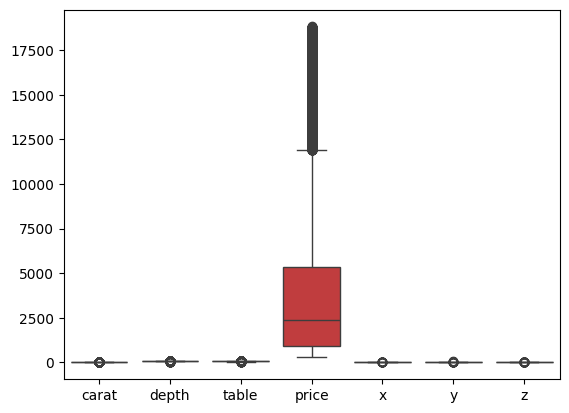

In [14]:
cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']

sns.boxplot(data=df[cols])
plt.show()

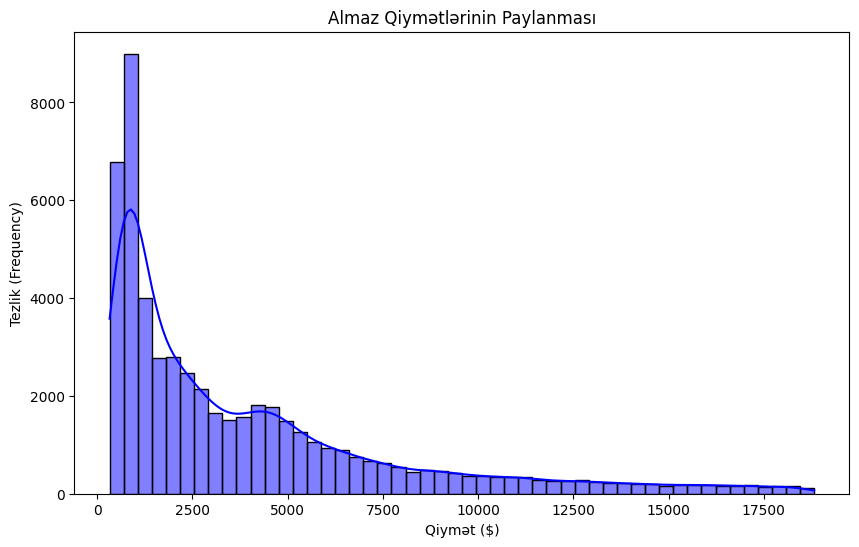

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(df1['price'], kde=True, color='blue', bins=50)

plt.title('Almaz Qiymətlərinin Paylanması')
plt.xlabel('Qiymət ($)')
plt.ylabel('Tezlik (Frequency)')
plt.show()

In [16]:
df2=df1

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
num_feature=X_train.select_dtypes(include=np.number).columns

In [40]:
df2
# scale
# array to tensor
# tensor to tensordataset
#tensordataset to dataloader
# train and eval
# checkpoint / save

,carat,depth,table,price,x,y,z,clarity_encoded,cut_encoded,color_encoded,price_log
0,0.23,61.5,55.0,326,3.95,3.98,2.43,2,5,6,5.789960
1,0.21,59.8,61.0,326,3.89,3.84,2.31,3,4,6,5.789960
2,0.23,56.9,65.0,327,4.05,4.07,2.31,5,2,6,5.793014
3,0.29,62.4,58.0,334,4.20,4.23,2.63,4,4,2,5.814131
4,0.31,63.3,58.0,335,4.34,4.35,2.75,2,2,1,5.817111
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,3,5,7,7.922261
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,3,2,7,7.922261
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,3,3,7,7.922261
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,2,4,3,7.922261


In [19]:
num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])
estimator=LinearRegression()
full_pipeline=Pipeline([
    ('num_pipeline', num_pipeline),
    ('estimator', estimator)
])

In [20]:
full_pipeline.fit(X_train,y_train)

Pipeline(steps=[('num_pipeline',
                 Pipeline(steps=[('imputer', SimpleImputer()),
                                 ('scaler', StandardScaler())])),
                ('estimator', LinearRegression())])

In [21]:
full_pipeline.score(X_train,y_train)

0.907335736316707

In [22]:
full_pipeline.score(X_test,y_test)

0.9056643685073514

In [23]:
r2_score(y_test,full_pipeline.predict(X_test))

0.9056643685073514

In [24]:
rf_estimator = RandomForestRegressor(n_estimators=100,
                                     max_depth=25,
                                     min_samples_split=5,
                                     max_features=1.0,
                                     random_state=42
                                     )
rf_pipeline = Pipeline([
    ('num_pipeline', num_pipeline),
    ('estimator', rf_estimator)
])

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('num_pipeline',
                 Pipeline(steps=[('imputer', SimpleImputer()),
                                 ('scaler', StandardScaler())])),
                ('estimator',
                 RandomForestRegressor(max_depth=25, min_samples_split=5,
                                       random_state=42))])

In [25]:
rf_pipeline.score(X_train,y_train),rf_pipeline.score(X_test,y_test),r2_score(y_test,rf_pipeline.predict(X_test))

(0.995958875483178, 0.9817289262545081, 0.9817289262545081)

In [26]:
param_grid = {
    'estimator__n_estimators': [100, 200],
    'estimator__max_depth': [15, 25, None],
    'estimator__min_samples_split': [2, 5],
    'estimator__max_features': ['sqrt', 1.0]
}
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

In [27]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=3,
    cv=3,
    n_jobs=-1,
    verbose=1
)
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('num_pipeline',
                                              Pipeline(steps=[('imputer',
                                                               SimpleImputer()),
                                                              ('scaler',
                                                               StandardScaler())])),
                                             ('estimator',
                                              RandomForestRegressor(max_depth=25,
                                                                    min_samples_split=5,
                                                                    random_state=42))]),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'estimator__max_depth': [15, 25, None],
                                        'estimator__max_features': ['sqrt',
                                                                    1.0],
                                        'estimator__min_samples_split': [2, 5],
                                        'estimator__n_estimators': [100, 200]},
                   verbose=1)

In [28]:
print(random_search.best_params_)
print(f"\nƏn yaxşı CV R2 Score: {random_search.best_score_:.4f}")

{'estimator__n_estimators': 200, 'estimator__min_samples_split': 5, 'estimator__max_features': 1.0, 'estimator__max_depth': 25}

Ən yaxşı CV R2 Score: 0.9811


--- Ən Vacib Sütunlar ---
           Feature  Importance
0            carat    0.632253
4                y    0.257359
6  clarity_encoded    0.063159
8    color_encoded    0.031049
3                x    0.004858
5                z    0.004835
1            depth    0.002782
2            table    0.002016
7      cut_encoded    0.001690


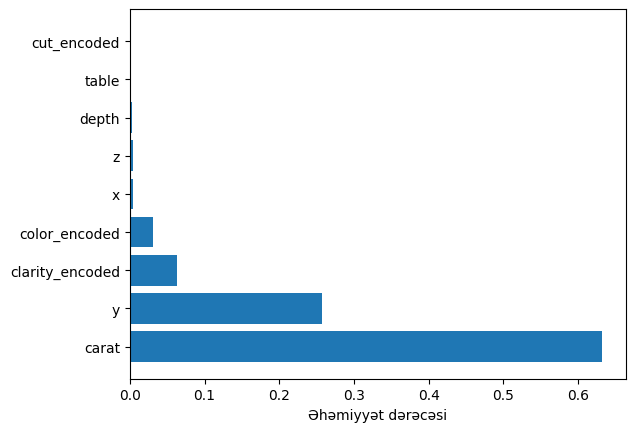

In [29]:
best_rf = random_search.best_estimator_.named_steps['estimator']
feature_names = X_train.columns
importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("--- Ən Vacib Sütunlar ---")
print(feature_importance_df)

plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Əhəmiyyət dərəcəsi')
plt.show()

In [30]:
xgb_estimator = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

xgb_pipeline = Pipeline([
    ('num_pipeline', num_pipeline),
    ('estimator', xgb_estimator)
])

xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('num_pipeline',
                 Pipeline(steps=[('imputer', SimpleImputer()),
                                 ('scaler', StandardScaler())])),
                ('estimator',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, featur...hts=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [31]:
y_pred_xgb = xgb_pipeline.predict(X_test)
train_score_xgb = xgb_pipeline.score(X_train, y_train)
test_score_xgb = xgb_pipeline.score(X_test, y_test)
r2_score_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f"XGBoost Train Score: {train_score_xgb:.4f}")
print(f"XGBoost Test Score: {test_score_xgb:.4f}")
print(f"XGBoost R2 Score : {test_score_xgb:.4f}")
print(f"XGBoost Orta Səhv (MAE): ${mae_xgb:.2f}")

XGBoost Train Score: 0.9899
XGBoost Test Score: 0.9824
XGBoost R2 Score : 0.9824
XGBoost Orta Səhv (MAE): $264.89


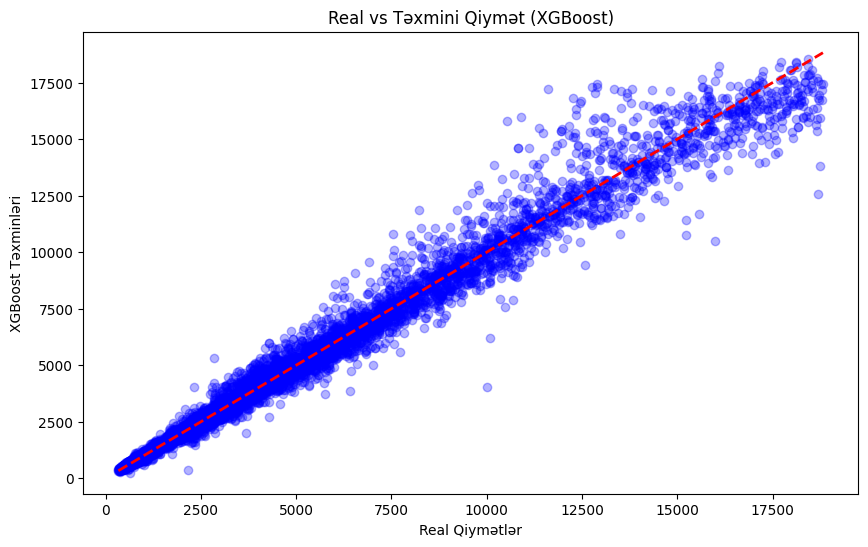

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Real Qiymətlər')
plt.ylabel('XGBoost Təxminləri')
plt.title('Real vs Təxmini Qiymət (XGBoost)')
plt.show()

In [33]:
df2['price_log'] = np.log1p(df2['price'])
X2 = df2.drop(columns=['price', 'price_log'])
y2 = df2['price_log']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)
xgb_pipeline.fit(X2_train, y2_train)
y_pred_log = xgb_pipeline.predict(X2_test)
y_pred_original = np.expm1(y_pred_log) # e^x - 1
y_test_original = np.expm1(y2_test)
new_mae = mean_absolute_error(y_test_original, y_pred_original)
new_r2 = r2_score(y_test_original, y_pred_original)

print(f"Log Transformation sonrası MAE: ${new_mae:.2f}")
print(f"Log Transformation sonrası R2: {new_r2:.4f}")

Log Transformation sonrası MAE: $260.72
Log Transformation sonrası R2: 0.9827


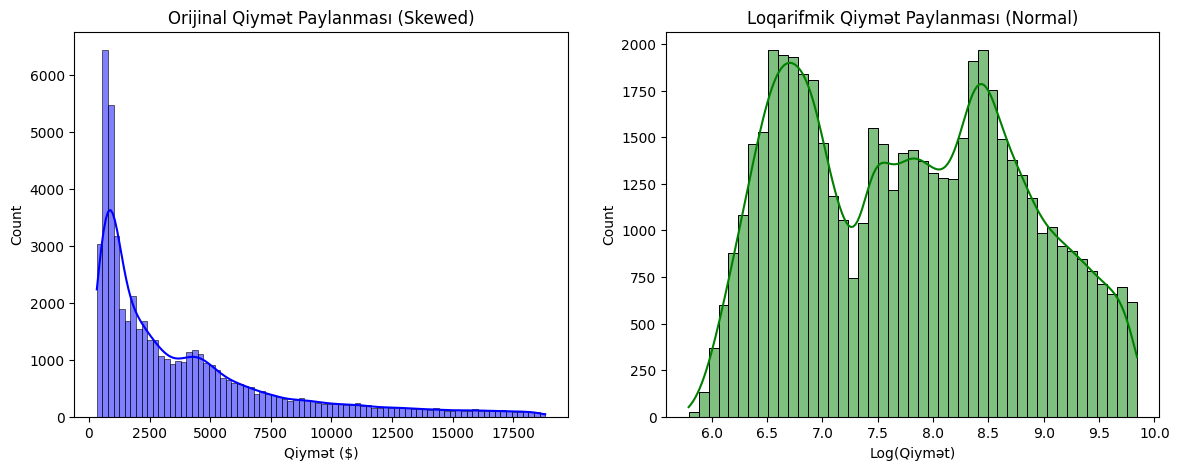

In [34]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df2['price'], kde=True, color='blue')
plt.title('Orijinal Qiymət Paylanması (Skewed)')
plt.xlabel('Qiymət ($)')

plt.subplot(1, 2, 2)
sns.histplot(df2['price_log'], kde=True, color='green')
plt.title('Loqarifmik Qiymət Paylanması (Normal)')
plt.xlabel('Log(Qiymət)')

plt.show()

In [35]:
df2.columns

Index(['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'clarity_encoded',
       'cut_encoded', 'color_encoded', 'price_log'],
      dtype='object')

In [36]:
def almaz_qiymeti_tahmin_et(model, carat, depth, table, x, y, z,clarity_encoded,cut_encoded,color_encoded):
    data = {
        'carat': [carat],
        'depth': [depth],
        'table': [table],
        'x': [x],
        'y': [y],
        'z': [z],
        'clarity_encoded':[clarity_encoded],
        'cut_encoded':[cut_encoded],
        'color_encoded':[color_encoded]
    }
    input_df = pd.DataFrame(data)
    log_pred = model.predict(input_df)
    real_pred = np.expm1(log_pred)
    return real_pred[0]
print("Test funksiyası hazırdır!")

Test funksiyası hazırdır!


In [37]:
tahmin_edilen_qiymet = almaz_qiymeti_tahmin_et(
    xgb_pipeline,
    carat=1.5,
    depth=62.2,
    table=58.0,
    x=7.30,
    y=7.25,
    z=4.50,
    clarity_encoded=4,
    cut_encoded=4,
    color_encoded=4
)
print(f"Bu almazın təxmini qiyməti: ${tahmin_edilen_qiymet:.2f}") # texminen 10000-13000 arasi alinmalidir

Bu almazın təxmini qiyməti: $12558.93


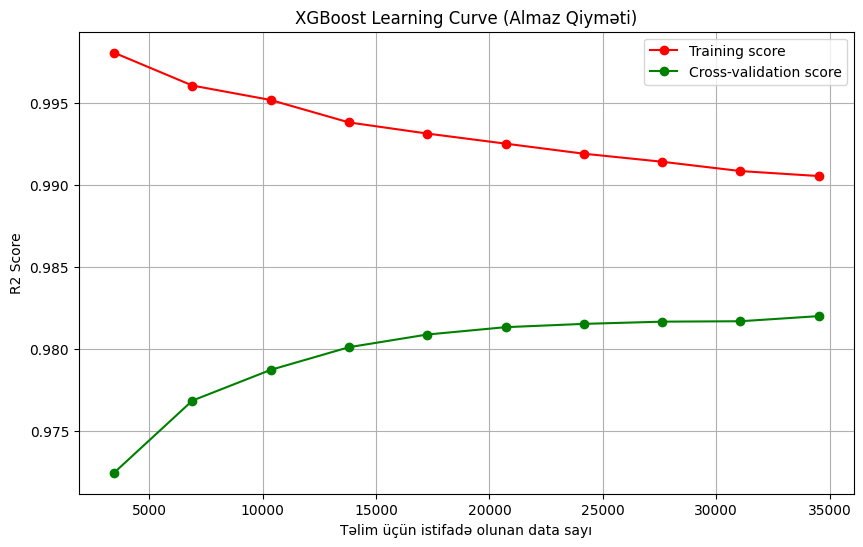

In [38]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )

    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

    plt.title(title)
    plt.xlabel("Təlim üçün istifadə olunan data sayı")
    plt.ylabel("R2 Score")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

plot_learning_curve(xgb_pipeline, X_train, y_train, "XGBoost Learning Curve (Almaz Qiyməti)")